In [ ]:
from data_generator import data_generator as dg
from pymc_marketing.mmm import MMM, GeometricAdstock, LogisticSaturation
from pymc_marketing.mmm.transformers import geometric_adstock, logistic_saturation
import numpy as np
import matplotlib.pyplot as plt
import arviz as az

plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.dpi"] = 100


np.random.seed(10)

# Set parameters for data generator
start_date = "2021-01-01"
periods = 52 * 3
channels = ["tv", "social", "search"]
adstock_alphas = [0.50, 0.25, 0.05]
saturation_lamdas = [1.5, 2.5, 3.5]
betas = [350, 150, 50]
spend_scalars = [10, 15, 20]

df = dg(start_date, periods, channels, spend_scalars, adstock_alphas, saturation_lamdas, betas)

# Scale betas using maximum sales value - this is so it is comparable to the fitted beta from pymc (pymc does feature and target scaling using MaxAbsScaler from sklearn)
betas_scaled = [
    ((df["tv_sales"] / df["sales"].max()) / df["tv_saturated"]).mean(),
    ((df["social_sales"] / df["sales"].max()) / df["social_saturated"]).mean(),
    ((df["search_sales"] / df["sales"].max()) / df["search_saturated"]).mean()
]

# Calculate contributions
contributions = np.asarray([
    round((df["tv_sales"].sum() / df["sales"].sum()), 2),
    round((df["social_sales"].sum() / df["sales"].sum()), 2),
    round((df["search_sales"].sum() / df["sales"].sum()), 2),
    round((df["demand"].sum() / df["sales"].sum()), 2)
])

df[["date", "demand", "demand_proxy", "tv_spend_raw", "social_spend_raw", "search_spend_raw", "sales"]]

e:\miniconda\envs\marketing_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,date,demand,demand_proxy,tv_spend_raw,social_spend_raw,search_spend_raw,sales
0,2021-01-03,356.003195,330.831226,5501.441206,5894.908137,7182.864568,489.566208
1,2021-01-10,301.006385,317.461345,2507.942445,5791.555554,6312.367780,441.138691
2,2021-01-17,81.538923,89.223970,1049.661462,1081.642708,1429.740857,152.309451
3,2021-01-24,241.765941,169.729439,3008.937195,5323.913163,6185.584938,367.160745
4,2021-01-31,311.145259,349.047382,3171.490614,6830.642777,7227.783598,465.083840
...,...,...,...,...,...,...,...
151,2023-11-26,504.966471,517.052302,4065.830904,10716.104909,9975.069784,743.618076
152,2023-12-03,604.005118,633.299525,3740.575561,7287.215373,16792.317339,822.314394
153,2023-12-10,525.265482,438.144702,6442.185846,11242.173092,6893.282177,763.558935
154,2023-12-17,458.850104,581.817816,4555.589865,3870.492537,6558.943829,646.468794


In [6]:
import pandas as pd
import numpy as np
import pytensor.tensor as pt
import pytensor.xtensor as ptx
from pymc_marketing.mmm.transformers import geometric_adstock, logistic_saturation

def exp_generator(start_date, periods, channel, adstock_alpha, saturation_lamda, 
                  beta, weekly_spend, max_abs_spend, freq="W"):
    
    # 0. Create time dimension
    date_range = pd.date_range(start=start_date, periods=periods, freq=freq)
    df_exp = pd.DataFrame({'date': date_range})

    # 1. Create raw channel spend
    df_exp[f"{channel}_spend_raw"] = weekly_spend

    # 2. Scale channel spend
    df_exp[f"{channel}_spend"] = df_exp[f"{channel}_spend_raw"] / max_abs_spend

    # 3. Apply adstock transformation
    spend_array = df_exp[f"{channel}_spend"].to_numpy().astype(float)
    spend_xt = ptx.as_xtensor(
        pt.as_tensor_variable(spend_array),
        dims=('time',)           # ← must pass dims here
    )
    df_exp[f"{channel}_adstock"] = geometric_adstock(
        x=spend_xt,
        alpha=adstock_alpha,
        l_max=8,
        normalize=True,
        dim='time'
    ).eval().flatten()

    # 4. Apply saturation transformation
    adstock_array = df_exp[f"{channel}_adstock"].to_numpy().astype(float)
    adstock_xt = ptx.as_xtensor(
        pt.as_tensor_variable(adstock_array),
        dims=('time',)           # ← same fix for saturation input
    )
    df_exp[f"{channel}_saturated"] = logistic_saturation(
        x=adstock_xt,
        lam=saturation_lamda
    ).eval().flatten()

    # 5. Calculate contribution to sales
    df_exp[f"{channel}_sales"] = df_exp[f"{channel}_saturated"] * beta

    return df_exp

In [7]:
# Set parameters for experiment generator
start_date = "2024-10-01"
periods = 8
channel = "tv"
adstock_alpha = adstock_alphas[0]
saturation_lamda = saturation_lamdas[0]
beta = betas[0]
weekly_spend = df["tv_spend_raw"].mean()
max_abs_spend = df["tv_spend_raw"].max()

df_exp_tv = exp_generator(start_date, periods, channel, adstock_alpha, saturation_lamda, beta, weekly_spend, max_abs_spend)

df_exp_tv

,date,tv_spend_raw,tv_spend,tv_adstock,tv_saturated,tv_sales
0,2024-10-06,3988.314882,0.31291,0.157069,0.117260,41.040836
1,2024-10-13,3988.314882,0.31291,0.235603,0.174886,61.210012
2,2024-10-20,3988.314882,0.31291,0.274870,0.203281,71.148320
3,2024-10-27,3988.314882,0.31291,0.294504,0.217354,76.074061
4,2024-11-03,3988.314882,0.31291,0.304320,0.224358,78.525260
5,2024-11-10,3988.314882,0.31291,0.309229,0.227851,79.747841
6,2024-11-17,3988.314882,0.31291,0.311683,0.229595,80.358366
7,2024-11-24,3988.314882,0.31291,0.312910,0.230467,80.663435


In [8]:
weekly_sales = df_exp_tv["tv_sales"].mean()

weekly_sales



np.float64(71.09601635209634)

In [9]:
df_lift_test = pd.DataFrame({
    "channel": ["tv_spend_raw"],
    "x": [0],
    "delta_x": weekly_spend,
    "delta_y": weekly_sales,
    "sigma": [weekly_sales * 0.05],
    }
)

df_lift_test

,channel,x,delta_x,delta_y,sigma
0,tv_spend_raw,0,3988.314882,71.096016,3.554801


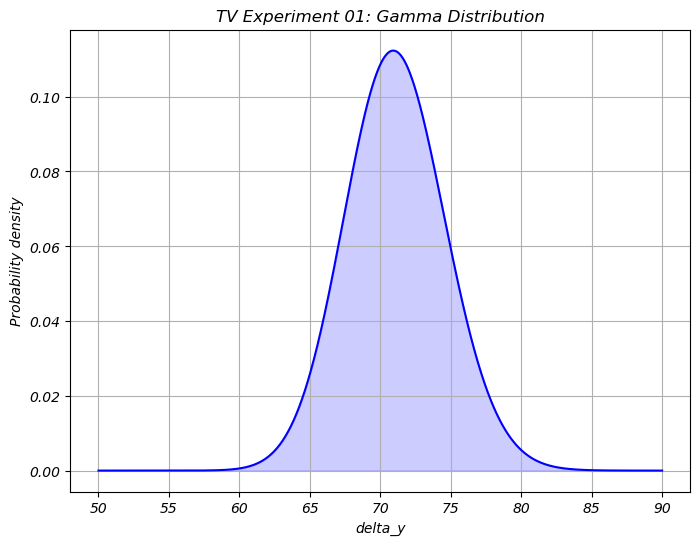

In [11]:
from scipy.stats import beta, gamma, halfnorm, laplace, norm, truncnorm
import matplotlib.pyplot as plt
mu = df_lift_test["delta_y"]
sigma = df_lift_test["sigma"]

beta = mu / sigma**2
alpha = mu * beta

x2 = np.linspace(50, 90, 1000)
y2 = gamma.pdf(x2, a=alpha, scale=1/beta)

plt.figure(figsize=(8, 6))
plt.plot(x2, y2, 'b-')
plt.fill_between(x2, y2, alpha=0.2, color='blue')
plt.title('TV Experiment 01: Gamma Distribution')
plt.xlabel('delta_y')
plt.ylabel('Probability density')
plt.grid(True)
plt.show()

# calibrate model

In [12]:
# set date column
date_col = "date"

# set outcome column
y_col = "sales"

# set marketing variables
channel_cols = ["tv_spend_raw",
                "social_spend_raw",
                "search_spend_raw"]

# set control variables
control_cols = ["demand_proxy"]

# create arrays
X = df[[date_col] + channel_cols + control_cols]
y = df[y_col]

# set test (out-of-sample) length
test_len = 8

# create train and test indexs
train_idx = slice(0, len(df) - test_len)
out_of_time_idx = slice(len(df) - test_len, len(df))

In [13]:


mmm_default = MMM.load("./mmm_default.nc")
mmm_default.add_lift_test_measurements(df_lift_test)
mmm_default.fit(X[train_idx], y[train_idx])



e:\miniconda\envs\marketing_env\Lib\site-packages\pymc_marketing\mmm\mmm.py:1117: FutureWarning: adstock_from_dict is deprecated and will be removed in 0.20.0. Use `from pymc_marketing.serialization import serialization; serialization.deserialize(data)` instead.
  "adstock": adstock_from_dict(adstock_dict),
e:\miniconda\envs\marketing_env\Lib\site-packages\pymc_marketing\mmm\mmm.py:1118: FutureWarning: saturation_from_dict is deprecated and will be removed in 0.20.0. Use `from pymc_marketing.serialization import serialization; serialization.deserialize(data)` instead.
  "saturation": saturation_from_dict(saturation_dict),
e:\miniconda\envs\marketing_env\Lib\site-packages\pydantic\_internal\_validate_call.py:137: FutureWarning: 
            The MMM class is deprecated and will be removed in a future version (in version 0.20.0).
            Please use the multidimensional MMM class instead.
            That is, `from pymc_marketing.mmm.multidimensional import MMM`.
            All our do

e:\miniconda\envs\marketing_env\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 91 seconds.
There were 3 divergences after tuning. Increase `target_accept` or reparameterize.


e:\miniconda\envs\marketing_env\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data
	> constant_data
	> fit_data

# validate model

In [14]:
mmm_default.idata["sample_stats"]["diverging"].sum().item()

3

In [16]:
import arviz as az
az.summary(
    data=mmm_default.fit_result,
    var_names=[
        "intercept",
        "y_sigma",
        "saturation_beta",
        "saturation_lam",
        "adstock_alpha",
        "gamma_control",
    ],
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
intercept,-0.005,0.028,-0.057,0.042,0.001,0.001,1565.0,1909.0,1.0
y_sigma,0.036,0.002,0.032,0.040,0.000,0.000,2657.0,2022.0,1.0
saturation_beta[tv_spend_raw],0.470,0.341,0.123,1.042,0.010,0.017,1719.0,1679.0,1.0
saturation_beta[social_spend_raw],0.264,0.059,0.183,0.334,0.002,0.011,1482.0,1338.0,1.0
saturation_beta[search_spend_raw],0.251,0.199,0.086,0.525,0.005,0.017,1503.0,1423.0,1.0
saturation_lam[tv_spend_raw],1.130,0.576,0.189,2.150,0.013,0.008,1746.0,1754.0,1.0
saturation_lam[social_spend_raw],3.582,0.879,1.930,5.198,0.026,0.023,1242.0,1038.0,1.0
saturation_lam[search_spend_raw],2.211,1.074,0.316,4.078,0.023,0.018,1959.0,1312.0,1.0
adstock_alpha[tv_spend_raw],0.264,0.099,0.075,0.448,0.002,0.002,1964.0,1112.0,1.0
adstock_alpha[social_spend_raw],0.250,0.105,0.038,0.432,0.003,0.002,1615.0,1379.0,1.0


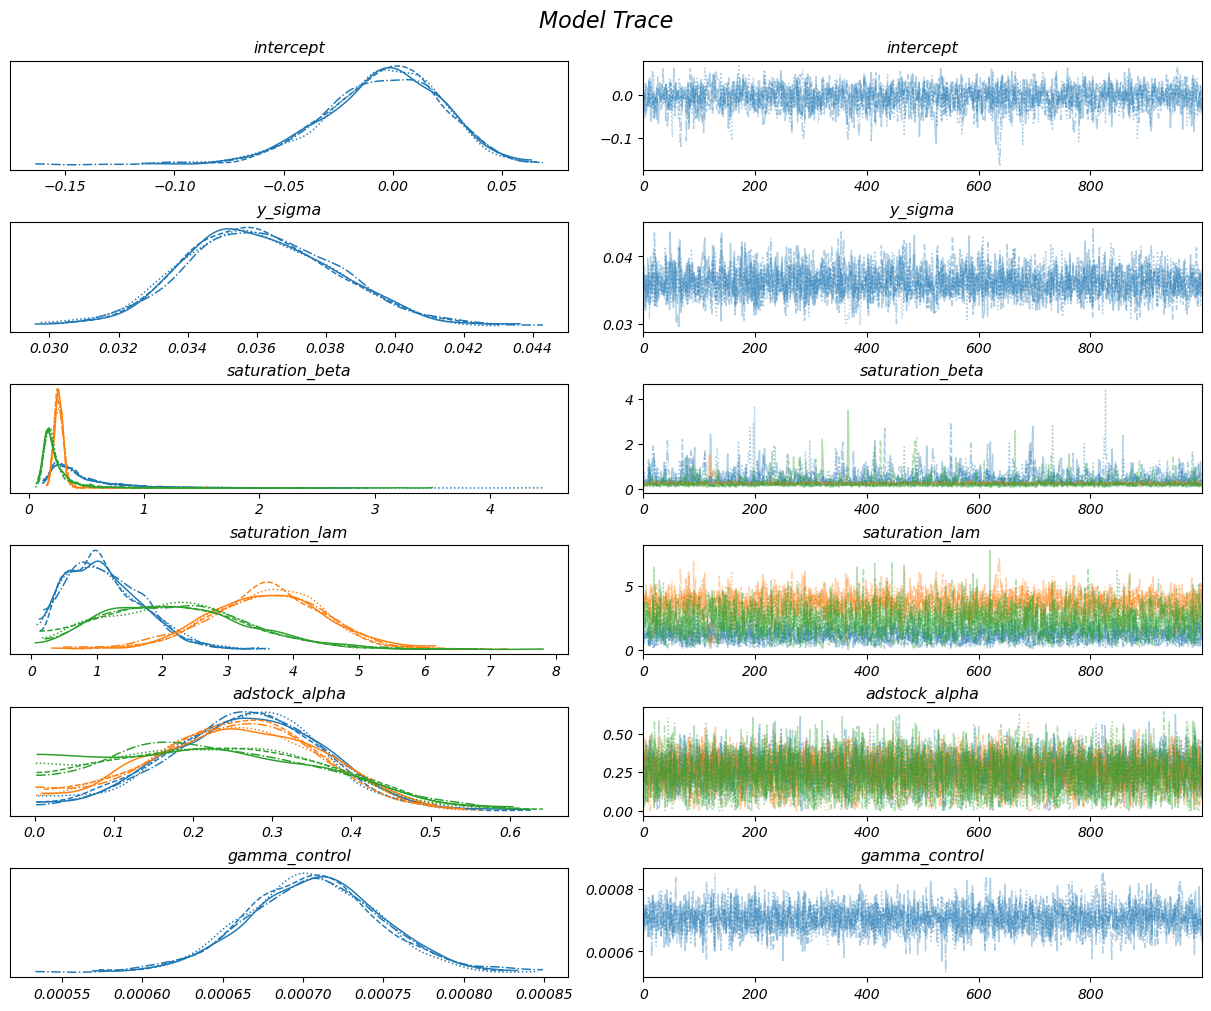

In [17]:
_ = az.plot_trace(
    data=mmm_default.fit_result,
    var_names=[
        "intercept",
        "y_sigma",
        "saturation_beta",
        "saturation_lam",
        "adstock_alpha",
        "gamma_control",
    ],
    compact=True,
    backend_kwargs={"figsize": (12, 10), "layout": "constrained"},
)
plt.gcf().suptitle("Model Trace", fontsize=16);

In [18]:


mmm_default.sample_posterior_predictive(X[train_idx], extend_idata=True, combined=True)



Sampling: [lift_measurements, y]


e:\miniconda\envs\marketing_env\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

e:\miniconda\envs\marketing_env\Lib\site-packages\pymc_marketing\mmm\mmm.py:2470: FutureWarning: Deleting a single level of a MultiIndex is deprecated. Previously, this deleted all levels of a MultiIndex. Please also drop the following variables: {'sample'} to avoid an error in the future.
  samples[var_name] *= self.target_scale


<xarray.Dataset> Size: 5MB
Dimensions:                 (date: 148, sample: 4000, _lift_measurements_dim: 1)
Coordinates:
  * date                    (date) datetime64[us] 1kB 2021-01-03 ... 2023-10-29
  * sample                  (sample) object 32kB MultiIndex
  * chain                   (sample) int64 32kB 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3
  * draw                    (sample) int64 32kB 0 1 2 3 4 ... 996 997 998 999
  * _lift_measurements_dim  (_lift_measurements_dim) int64 8B 0
Data variables:
    y                       (date, sample) float64 5MB 421.0 452.7 ... 612.0
    lift_measurements       (_lift_measurements_dim, sample) float64 32kB 0.0...
Attributes:
    created_at:                 2026-06-15T01:54:23.922809+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.28.5

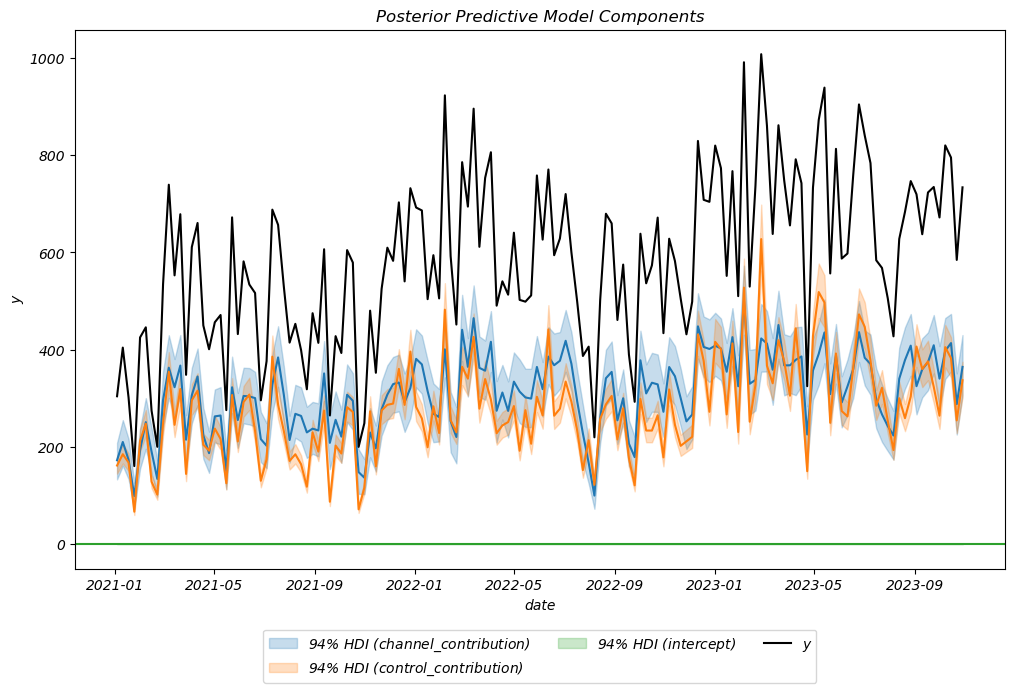

In [20]:
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.dpi"] = 100
mmm_default.plot_components_contributions(original_scale=True);

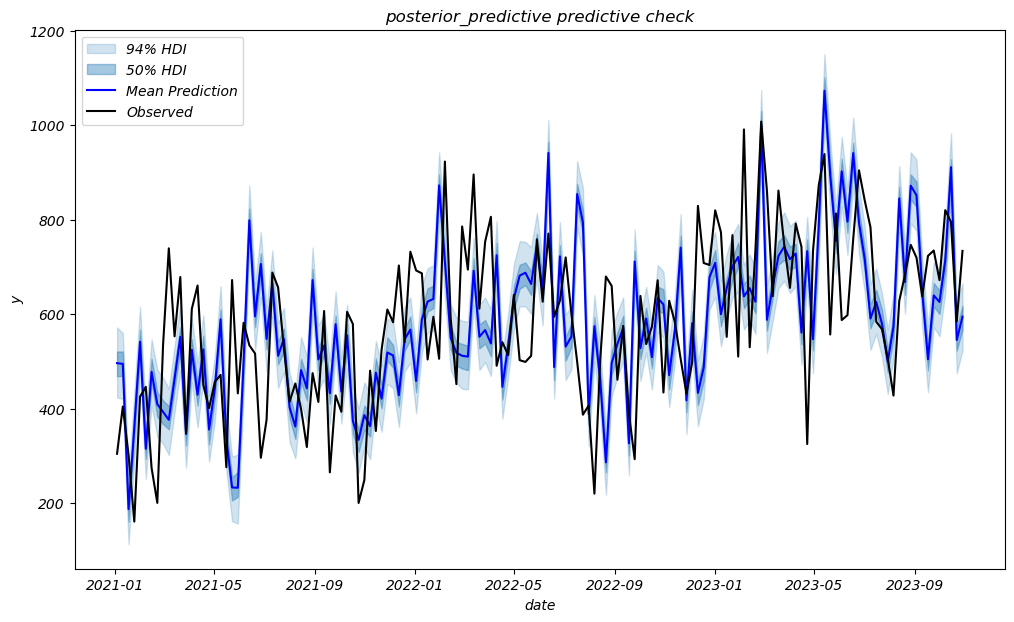

In [21]:

mmm_default.plot_posterior_predictive(original_scale=True);



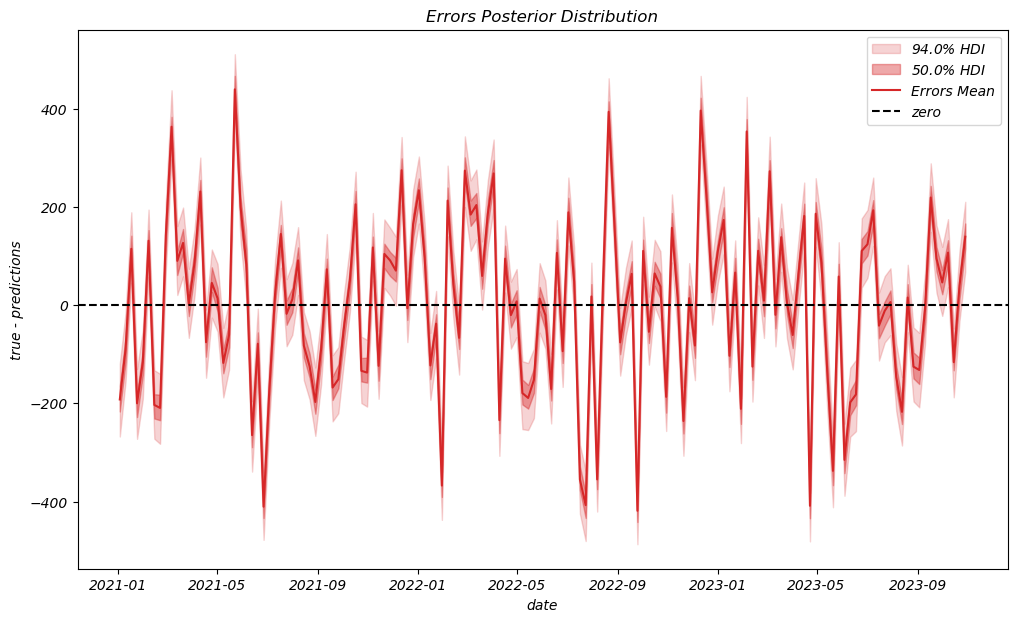

In [22]:
mmm_default.plot_errors(original_scale=True);

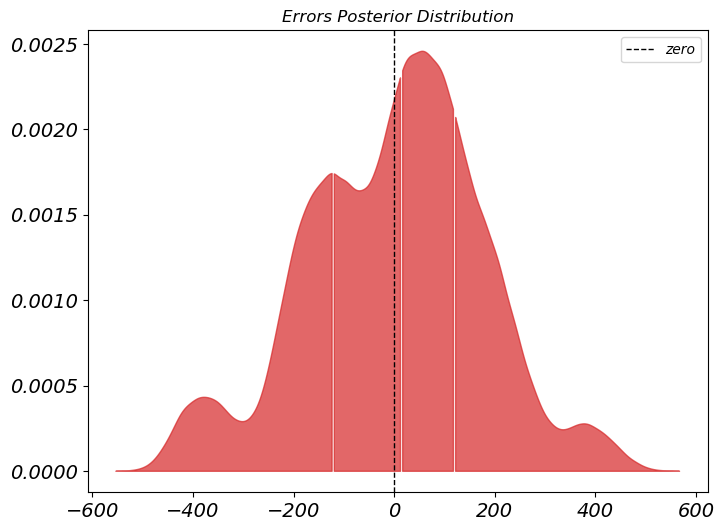

In [23]:

errors = mmm_default.get_errors(original_scale=True)

fig, ax = plt.subplots(figsize=(8, 6))
az.plot_dist(
    errors, quantiles=[0.25, 0.5, 0.75], color="C3", fill_kwargs={"alpha": 0.7}, ax=ax
)
ax.axvline(x=0, color="black", linestyle="--", linewidth=1, label="zero")
ax.legend()
ax.set(title="Errors Posterior Distribution");



Sampling: [lift_measurements, y]


e:\miniconda\envs\marketing_env\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

e:\miniconda\envs\marketing_env\Lib\site-packages\pymc_marketing\mmm\mmm.py:2470: FutureWarning: Deleting a single level of a MultiIndex is deprecated. Previously, this deleted all levels of a MultiIndex. Please also drop the following variables: {'sample'} to avoid an error in the future.
  samples[var_name] *= self.target_scale


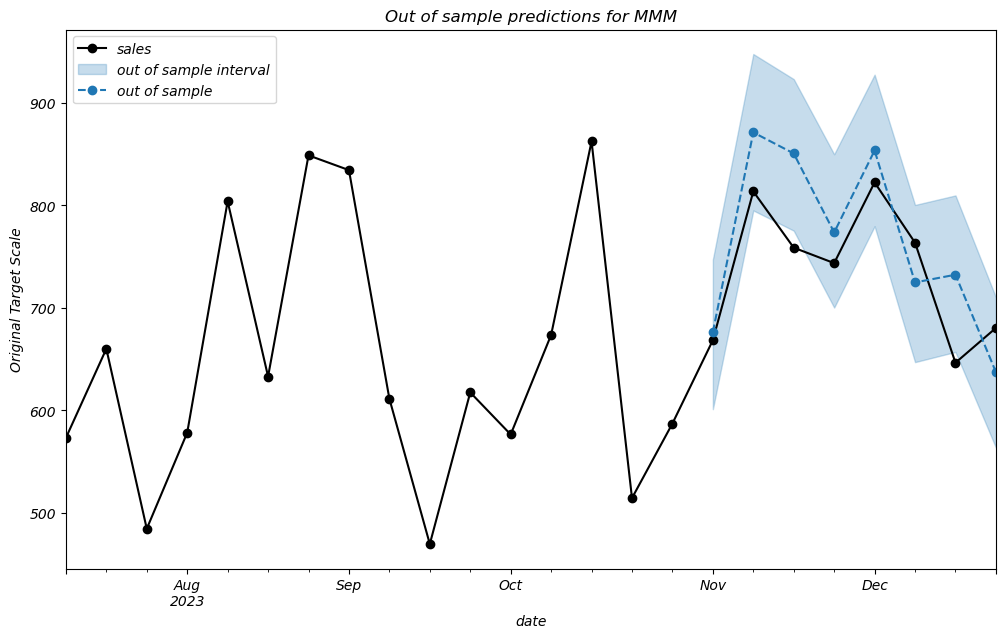

In [25]:
y_out_of_sample = mmm_default.sample_posterior_predictive(
    X_pred=X[out_of_time_idx], extend_idata=False, include_last_observations=True
)

def plot_in_sample(X, y, ax, n_points: int = 15):
    (
        y.to_frame()
        .set_index(X[date_col])
        .iloc[-n_points:]
        .plot(ax=ax, marker="o", color="black", label="actuals")
    )
    return ax


def plot_out_of_sample(X_out_of_sample, y_out_of_sample, ax, color, label):
    y_out_of_sample_groupby = y_out_of_sample["y"].to_series().groupby("date")
    
    lower, upper = quantiles = [0.025, 0.975]
    conf = y_out_of_sample_groupby.quantile(quantiles).unstack()
    
    dates = X_out_of_sample[date_col].values.astype("datetime64[ms]")  # ← fix
    
    ax.fill_between(
        dates,
        conf[lower].values,
        conf[upper].values,
        alpha=0.25,
        color=color,
        label=f"{label} interval",
    )
    
    mean = y_out_of_sample_groupby.mean()
    mean.index = mean.index.astype("datetime64[ms]")  # ← mismo fix para mean
    mean.plot(ax=ax, marker="o", label=label, color=color, linestyle="--")
    
    ax.set(ylabel="Original Target Scale", title="Out of sample predictions for MMM")
    return ax


_, ax = plt.subplots()
plot_in_sample(X, y, ax=ax, n_points=len(X[out_of_time_idx])*3)
plot_out_of_sample(
    X[out_of_time_idx], y_out_of_sample, ax=ax, label="out of sample", color="C0"
)
ax.legend(loc="upper left");

In [26]:


channels = np.array(["tv", "social", "search", "demand"])

true_contributions = pd.DataFrame({'Channels': channels, 'Contributions': contributions})
true_contributions= true_contributions.sort_values(by='Contributions', ascending=False).reset_index(drop=True)
true_contributions = true_contributions.style.bar(subset=['Contributions'], color='lightblue')

true_contributions



,Channels,Contributions
0,demand,0.700000
1,tv,0.140000
2,social,0.110000
3,search,0.050000


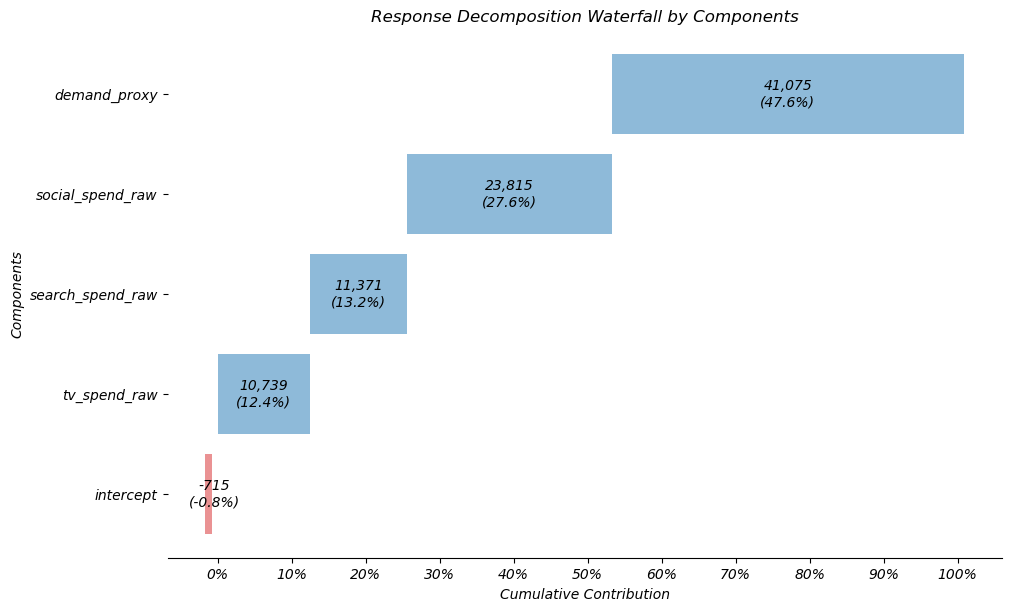

In [27]:


mmm_default.plot_waterfall_components_decomposition(figsize=(10,6));



In [28]:
dummy_model = MMM(
    date_column="",
    channel_columns=[""],
    adstock=GeometricAdstock(l_max=4),
    saturation=LogisticSaturation(),
)
dummy_model.default_model_config

e:\miniconda\envs\marketing_env\Lib\site-packages\pydantic\_internal\_validate_call.py:137: FutureWarning: 
            The MMM class is deprecated and will be removed in a future version (in version 0.20.0).
            Please use the multidimensional MMM class instead.
            That is, `from pymc_marketing.mmm.multidimensional import MMM`.
            All our documentation has been updated to reflect this change.
            Refer to the migration guide for more details: https://www.pymc-marketing.io/en/latest/notebooks/mmm/mmm_migration_guide.html
            
  res = self.__pydantic_validator__.validate_python(pydantic_core.ArgsKwargs(args, kwargs))


{'intercept': Prior("Normal", mu=0, sigma=2, dims=()),
 'likelihood': Prior("Normal", sigma=Prior("HalfNormal", sigma=2, dims=()), dims="date"),
 'gamma_control': Prior("Normal", mu=0, sigma=2, dims="control"),
 'gamma_fourier': Prior("Laplace", mu=0, b=1, dims="fourier_mode"),
 'adstock_alpha': Prior("Beta", alpha=1, beta=3, dims="channel"),
 'saturation_lam': Prior("Gamma", alpha=3, beta=1, dims="channel"),
 'saturation_beta': Prior("HalfNormal", sigma=2, dims="channel")}

In [30]:
from pymc_marketing.prior import Prior

model_config = {
    'intercept': Prior("Normal", mu=0, sigma=2),
    'likelihood': Prior("Normal", sigma=Prior("HalfNormal", sigma=2)),
    'gamma_control': Prior("Normal", mu=0, sigma=2, dims="control"),
    'gamma_fourier': Prior("Laplace", mu=0, b=1, dims="fourier_mode"),
    'adstock_alpha': Prior("Beta", alpha=1, beta=3, dims="channel"),
    'saturation_lam': Prior("Gamma", alpha=3, beta=1, dims="channel"),
    'saturation_beta': Prior("TruncatedNormal", mu=[0.02, 0.04, 0.01], lower=0, sigma=0.1, dims=("channel"))
}

mmm_with_priors = MMM(
    model_config=model_config,    
    adstock=GeometricAdstock(l_max=8),
    saturation=LogisticSaturation(),
    date_column=date_col,
    channel_columns=channel_cols,
    control_columns=control_cols,
)

In [32]:
mmm_with_priors.fit(X[train_idx], y[train_idx])

e:\miniconda\envs\marketing_env\Lib\site-packages\pymc_extras\prior.py:822: UserWarning: Implicit conversion of array-like parameter mu to DataArray with dims ('channel',). Use DataArray with explicit dims to avoid this warning
  return _param_value_with_dims(param, value, dims=self.dims)
e:\miniconda\envs\marketing_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, adstock_alpha, saturation_lam, saturation_beta, gamma_control, y_sig

e:\miniconda\envs\marketing_env\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 82 seconds.


e:\miniconda\envs\marketing_env\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data
	> constant_data
	> fit_data

In [33]:


mmm_with_priors.idata["sample_stats"]["diverging"].sum().item()



0

In [34]:
az.summary(
    data=mmm_with_priors.fit_result,
    var_names=[
        "intercept",
        "y_sigma",
        "saturation_beta",
        "saturation_lam",
        "adstock_alpha",
        "gamma_control",
    ],
)



,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
intercept,-0.011,0.019,-0.047,0.024,0.000,0.000,3228.0,2096.0,1.0
y_sigma,0.029,0.002,0.026,0.032,0.000,0.000,3334.0,2809.0,1.0
saturation_beta[tv_spend_raw],0.308,0.043,0.227,0.386,0.001,0.001,2689.0,2675.0,1.0
saturation_beta[social_spend_raw],0.186,0.025,0.139,0.233,0.000,0.000,3001.0,2808.0,1.0
saturation_beta[search_spend_raw],0.115,0.035,0.057,0.182,0.001,0.001,2834.0,2267.0,1.0
saturation_lam[tv_spend_raw],2.992,0.555,1.994,4.019,0.010,0.010,2806.0,2242.0,1.0
saturation_lam[social_spend_raw],3.643,0.839,2.176,5.293,0.015,0.013,2978.0,2674.0,1.0
saturation_lam[search_spend_raw],2.629,1.015,0.896,4.521,0.018,0.017,2952.0,2993.0,1.0
adstock_alpha[tv_spend_raw],0.379,0.060,0.272,0.496,0.001,0.001,3492.0,2613.0,1.0
adstock_alpha[social_spend_raw],0.104,0.063,0.000,0.212,0.001,0.001,2152.0,1240.0,1.0


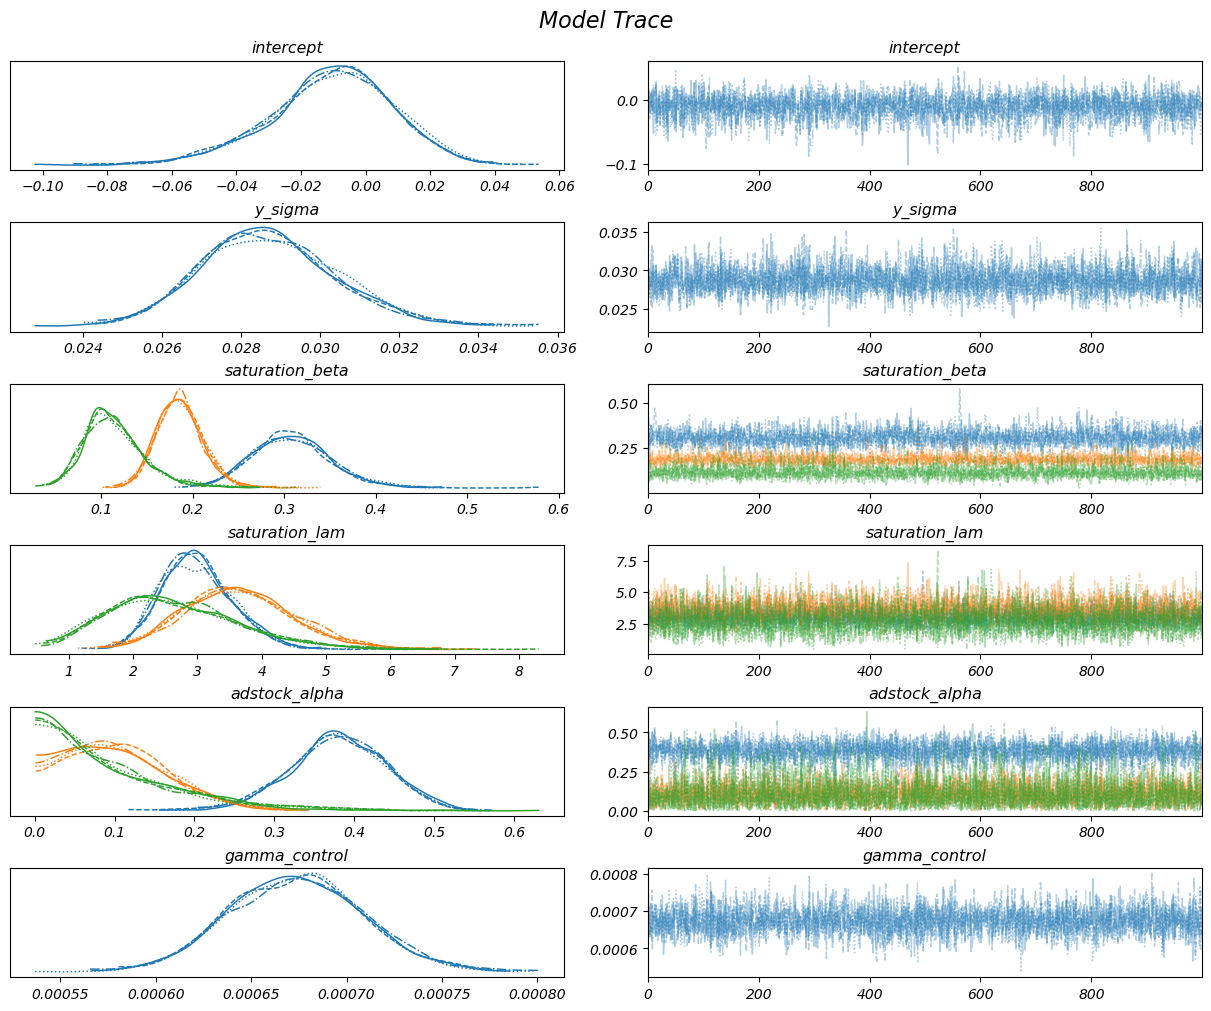

In [35]:
_ = az.plot_trace(
    data=mmm_with_priors.fit_result,
    var_names=[
        "intercept",
        "y_sigma",
        "saturation_beta",
        "saturation_lam",
        "adstock_alpha",
        "gamma_control",
    ],
    compact=True,
    backend_kwargs={"figsize": (12, 10), "layout": "constrained"},
)
plt.gcf().suptitle("Model Trace", fontsize=16);

In [36]:
mmm_with_priors.sample_posterior_predictive(X[train_idx], extend_idata=True, combined=True)

Sampling: [y]


e:\miniconda\envs\marketing_env\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

e:\miniconda\envs\marketing_env\Lib\site-packages\pymc_marketing\mmm\mmm.py:2470: FutureWarning: Deleting a single level of a MultiIndex is deprecated. Previously, this deleted all levels of a MultiIndex. Please also drop the following variables: {'sample'} to avoid an error in the future.
  samples[var_name] *= self.target_scale


<xarray.Dataset> Size: 5MB
Dimensions:  (date: 148, sample: 4000)
Coordinates:
  * date     (date) datetime64[us] 1kB 2021-01-03 2021-01-10 ... 2023-10-29
  * sample   (sample) object 32kB MultiIndex
  * chain    (sample) int64 32kB 0 0 0 0 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3 3 3 3 3
  * draw     (sample) int64 32kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
Data variables:
    y        (date, sample) float64 5MB 484.4 517.0 407.6 ... 553.3 612.8 590.4
Attributes:
    created_at:                 2026-06-15T02:08:49.874959+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.28.5

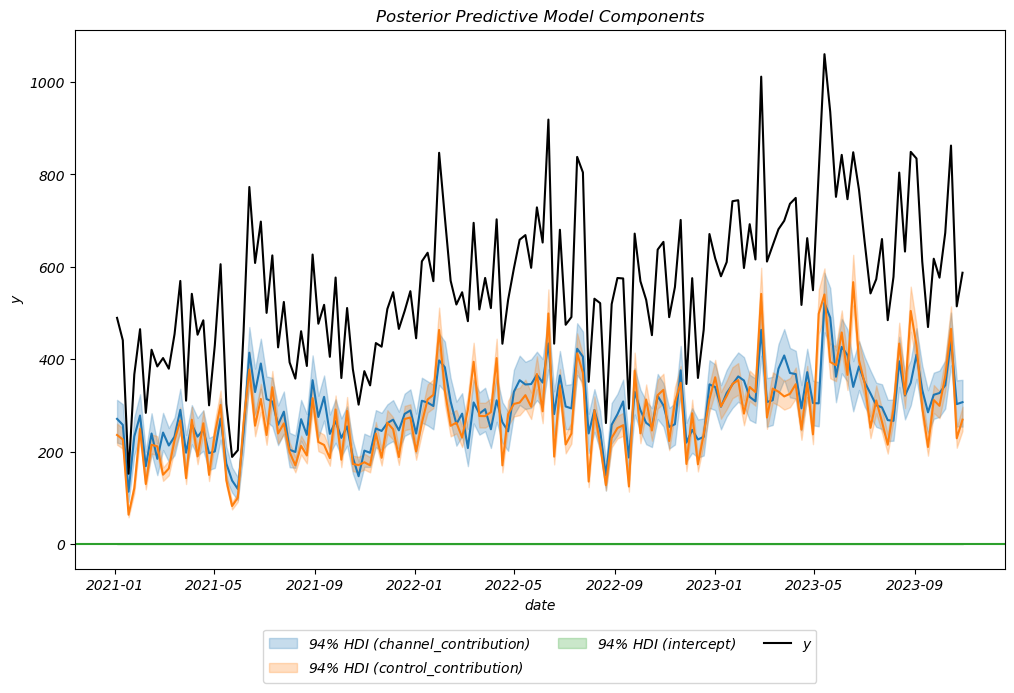

In [37]:
mmm_with_priors.plot_components_contributions(original_scale=True);



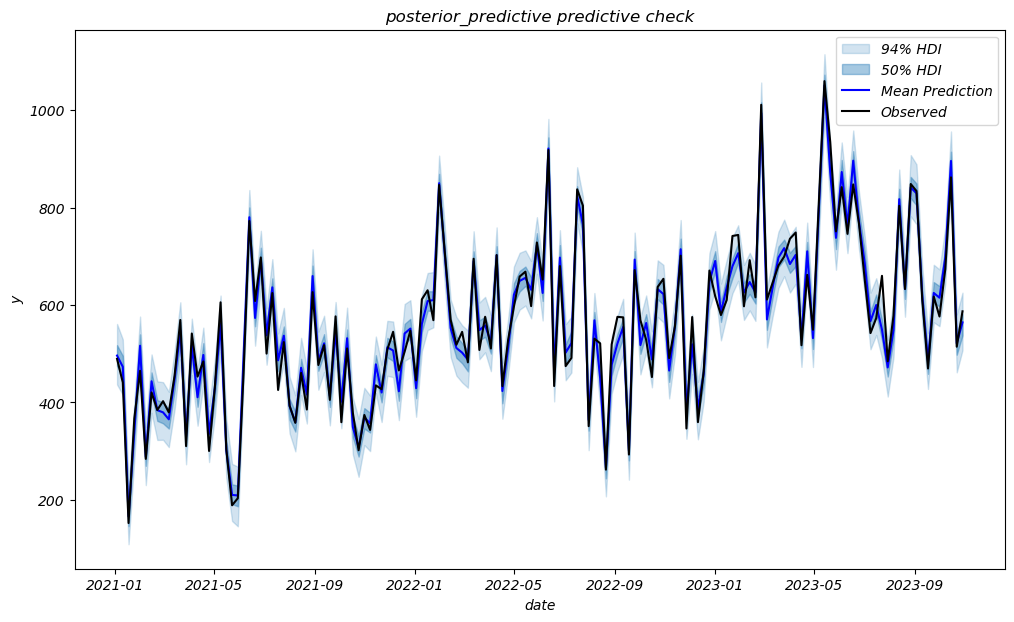

In [40]:
mmm_with_priors.plot_posterior_predictive(original_scale=True);

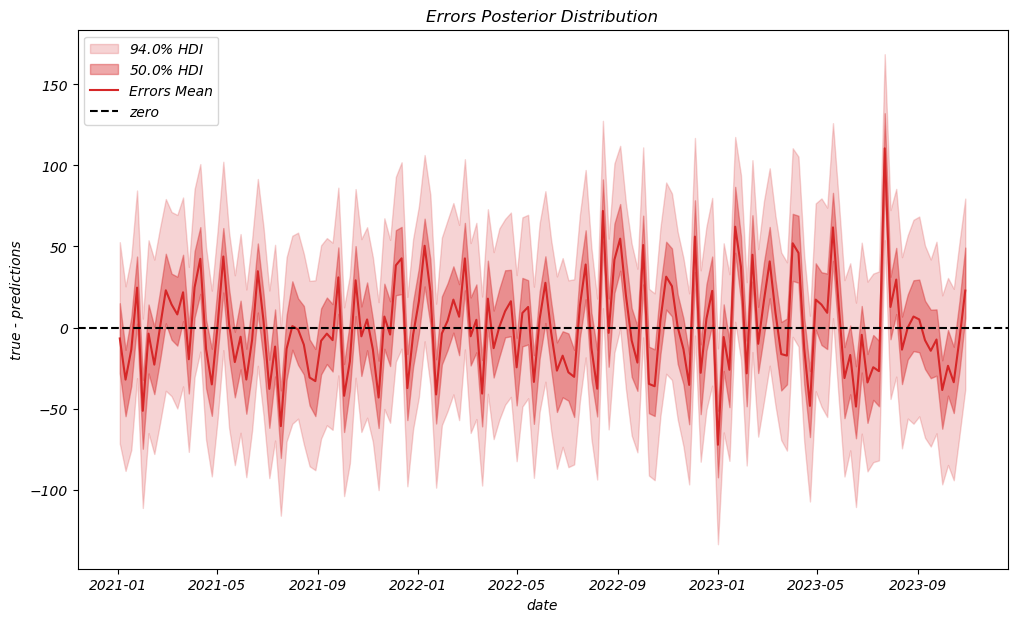

In [41]:
mmm_with_priors.plot_errors(original_scale=True);



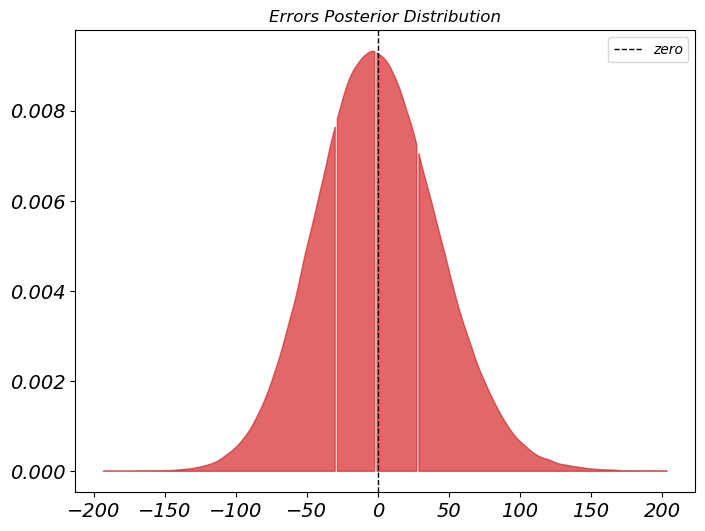

In [42]:
errors = mmm_with_priors.get_errors(original_scale=True)

fig, ax = plt.subplots(figsize=(8, 6))
az.plot_dist(
    errors, quantiles=[0.25, 0.5, 0.75], color="C3", fill_kwargs={"alpha": 0.7}, ax=ax
)
ax.axvline(x=0, color="black", linestyle="--", linewidth=1, label="zero")
ax.legend()
ax.set(title="Errors Posterior Distribution");



Sampling: [y]


e:\miniconda\envs\marketing_env\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

e:\miniconda\envs\marketing_env\Lib\site-packages\pymc_marketing\mmm\mmm.py:2470: FutureWarning: Deleting a single level of a MultiIndex is deprecated. Previously, this deleted all levels of a MultiIndex. Please also drop the following variables: {'sample'} to avoid an error in the future.
  samples[var_name] *= self.target_scale


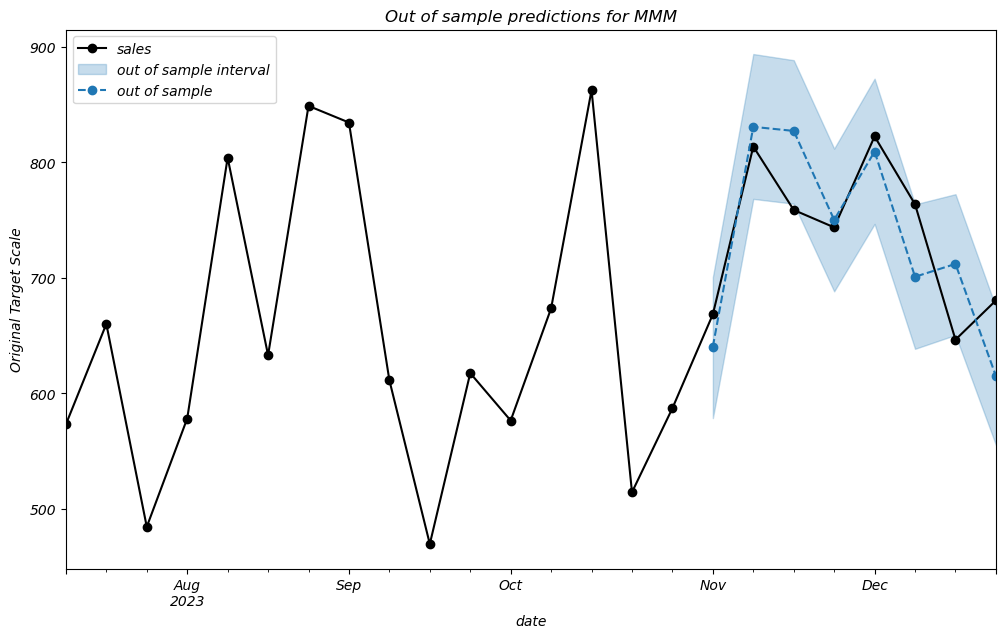

In [43]:
y_out_of_sample = mmm_with_priors.sample_posterior_predictive(
    X_pred=X[out_of_time_idx], extend_idata=False, include_last_observations=True
)

_, ax = plt.subplots()
plot_in_sample(X, y, ax=ax, n_points=len(X[out_of_time_idx])*3)
plot_out_of_sample(
    X[out_of_time_idx], y_out_of_sample, ax=ax, label="out of sample", color="C0"
)
ax.legend(loc="upper left");

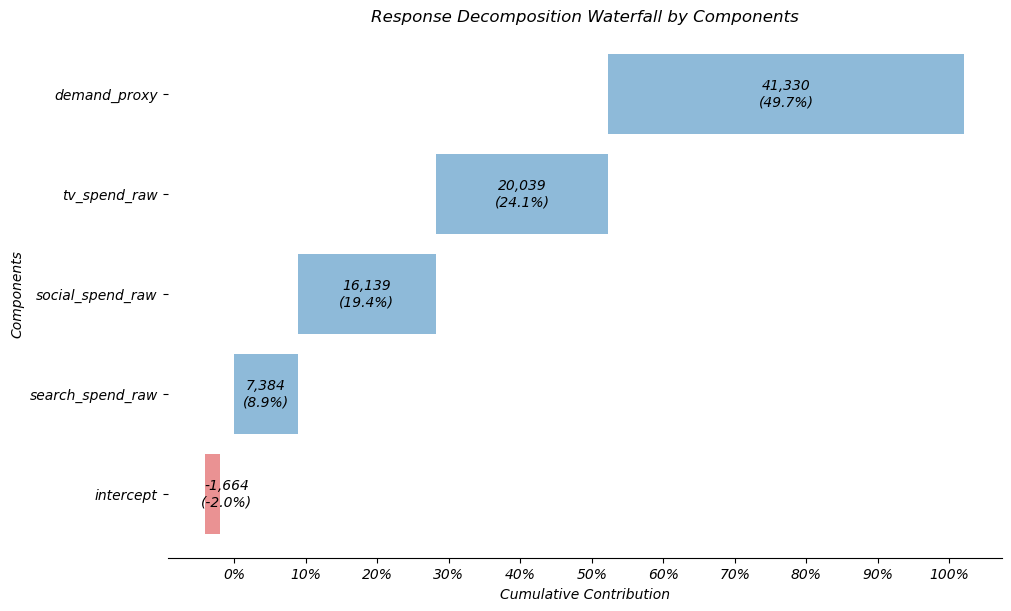

In [44]:
mmm_with_priors.plot_waterfall_components_decomposition(figsize=(10,6));

In [45]:

perc_change = 0.20
budget_len = 12
budget_idx = slice(len(df) - test_len, len(df))
recent_period = X[budget_idx][channel_cols]

recent_period



,tv_spend_raw,social_spend_raw,search_spend_raw
148,4223.983706,6887.972160,8829.905418
149,5242.930341,13159.274324,18088.903771
150,7423.276609,9763.455538,7451.072463
151,4065.830904,10716.104909,9975.069784
152,3740.575561,7287.215373,16792.317339
153,6442.185846,11242.173092,6893.282177
154,4555.589865,3870.492537,6558.943829
155,2637.616935,8490.789891,6587.909768


In [46]:
# set overall budget constraint (to the nearest £1k)
budget = round(recent_period.sum(axis=0).sum() / budget_len, -3)

# record the current budget split by channel
current_budget_split = round(recent_period.mean() / recent_period.mean().sum(), 2)

# set channel level constraints
lower_bounds = round(recent_period.min(axis=0) * (1 - perc_change))
upper_bounds = round(recent_period.max(axis=0) * (1 + perc_change))

budget_bounds = {
    channel: [lower_bounds[channel], upper_bounds[channel]]
    for channel in channel_cols
}

print(f'Overall budget constraint: {budget}')
print('Channel constraints:')
for channel, bounds in budget_bounds.items():
    print(f'  {channel}: Lower Bound = {bounds[0]}, Upper Bound = {bounds[1]}')

Overall budget constraint: 16000.0
Channel constraints:
  tv_spend_raw: Lower Bound = 2110.0, Upper Bound = 8908.0
  social_spend_raw: Lower Bound = 3096.0, Upper Bound = 15791.0
  search_spend_raw: Lower Bound = 5247.0, Upper Bound = 21707.0


In [47]:
model_granularity = "weekly"

allocation_strategy, optimization_result = mmm_default.optimize_budget(
    budget=budget,
    num_periods=budget_len,
    budget_bounds=budget_bounds,
    minimize_kwargs={
        "method": "SLSQP",
        "options": {"ftol": 1e-9, "maxiter": 5_000},
    },
)

response = mmm_default.sample_response_distribution(
    allocation_strategy=allocation_strategy,
    time_granularity=model_granularity,
    num_periods=budget_len,
    noise_level=0.05,
)



C:\Users\juane\AppData\Local\Temp\ipykernel_12648\1250348585.py:3: DeprecationWarning: This method is deprecated and will be removed in a future version. Please migrate to the `Multidimensal.MMM` class.
  allocation_strategy, optimization_result = mmm_default.optimize_budget(
e:\miniconda\envs\marketing_env\Lib\site-packages\pymc_marketing\mmm\budget_optimizer.py:808: UserWarning: Using default equality constraint
  self.set_constraints(
Sampling: [y]


In [48]:
opt_spend = pd.Series(allocation_strategy, index=recent_period.mean().index).to_frame(name="opt_spend")
opt_spend["avg_spend"] = budget * current_budget_split
opt_spend

,opt_spend,avg_spend
tv_spend_raw,5333.333333,3200.0
social_spend_raw,5333.333333,5920.0
search_spend_raw,5333.333333,6880.0


In [50]:

opt_spend.sum()



opt_spend    16000.0
avg_spend    16000.0
dtype: float64

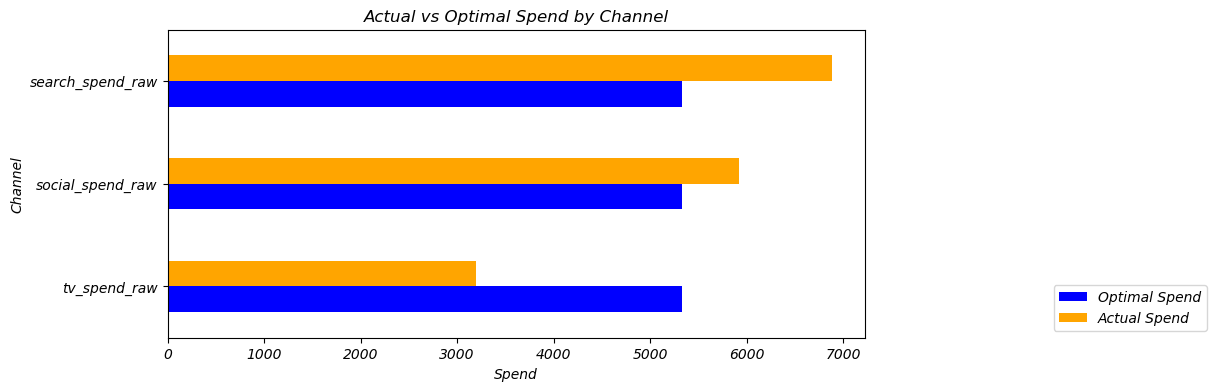

In [52]:

fig, ax = plt.subplots(figsize=(9, 4))
opt_spend.plot(kind='barh', ax=ax, color=['blue', 'orange'])

plt.xlabel("Spend")
plt.ylabel("Channel")
plt.title("Actual vs Optimal Spend by Channel")
plt.legend(["Optimal Spend", "Actual Spend"])
plt.legend(["Optimal Spend", "Actual Spend"], loc='lower right', bbox_to_anchor=(1.5, 0.0))

plt.show()



In [86]:
# create dataframe with avg spend
last_date = mmm_default.X["date"].max()
new_dates = pd.date_range(start=last_date, periods=1 + budget_len, freq="W-MON")[1:]
budget_scenario_avg = pd.DataFrame({"date": new_dates,})
budget_scenario_avg["tv_spend_raw"] = opt_spend["avg_spend"]["tv_spend_raw"]
budget_scenario_avg["social_spend_raw"] = opt_spend["avg_spend"]["social_spend_raw"]
budget_scenario_avg["search_spend_raw"] = opt_spend["avg_spend"]["search_spend_raw"]
budget_scenario_avg["demand_proxy"] = X[budget_idx][control_cols].mean()

# calculate overall contribution
scenario_contrib_avg  = mmm_default.sample_posterior_predictive(
    X_pred=budget_scenario_avg , extend_idata=False
)

avg_contrib = scenario_contrib_avg.mean(dim="sample").sum()["y"].values

Sampling: [lift_measurements, y]


e:\miniconda\envs\marketing_env\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

e:\miniconda\envs\marketing_env\Lib\site-packages\pymc_marketing\mmm\mmm.py:2470: FutureWarning: Deleting a single level of a MultiIndex is deprecated. Previously, this deleted all levels of a MultiIndex. Please also drop the following variables: {'sample'} to avoid an error in the future.
  samples[var_name] *= self.target_scale


In [89]:
opt_contrib

array(0.)

In [90]:
avg_contrib

array(0.)

In [82]:

print(f'% increase in sales: {round((opt_contrib / avg_contrib) - 1, 2)}')



% increase in sales: nan


C:\Users\juane\AppData\Local\Temp\ipykernel_12648\791343867.py:1: RuntimeWarning: invalid value encountered in divide
  print(f'% increase in sales: {round((opt_contrib / avg_contrib) - 1, 2)}')
